# Home Credit Default Risk & Exploratory Data Analysis


## Setup and data loading

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("../data/application_train.csv")
df = pd.read_csv(DATA_PATH)

print(f"Loaded {DATA_PATH}")
print(f"Shape: {df.shape}")
print(df.columns.tolist())

Loaded ..\data\application_train.csv
Shape: (307511, 122)
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEX

## Data structure and quality


In [2]:
display(df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

structure_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Numeric columns", "Categorical columns",
               "Duplicate rows", "Duplicate SK_ID_CURR"],
    "Value": [len(df), df.shape[1], len(numeric_cols), len(categorical_cols),
              df.duplicated().sum(), df["SK_ID_CURR"].duplicated().sum()],
})
display(structure_summary)

,Metric,Value
0,Rows,307511
1,Columns,122
2,Numeric columns,106
3,Categorical columns,16
4,Duplicate rows,0
5,Duplicate SK_ID_CURR,0


In [4]:
display(df.dtypes.value_counts().to_frame("column_count"))

,column_count
float64,65
int64,41
str,16


In [5]:
display(df[numeric_cols].describe())

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## Missing data analysis


In [6]:
missing_report = (
    df.isna().agg(["sum", "mean"]).T
      .rename(columns={"sum": "missing_count", "mean": "missing_pct"})
      .sort_values("missing_pct", ascending=False)
)
missing_report["missing_count"] = missing_report["missing_count"].astype(int)
missing_report["missing_pct"] *= 100

print(f"Columns with any missing values: {(missing_report.missing_count > 0).sum()}")
print(f"Columns with >50% missing: {(missing_report.missing_pct > 50).sum()}")
display(missing_report.head(25))


Columns with any missing values: 67
Columns with >50% missing: 41


,missing_count,missing_pct
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


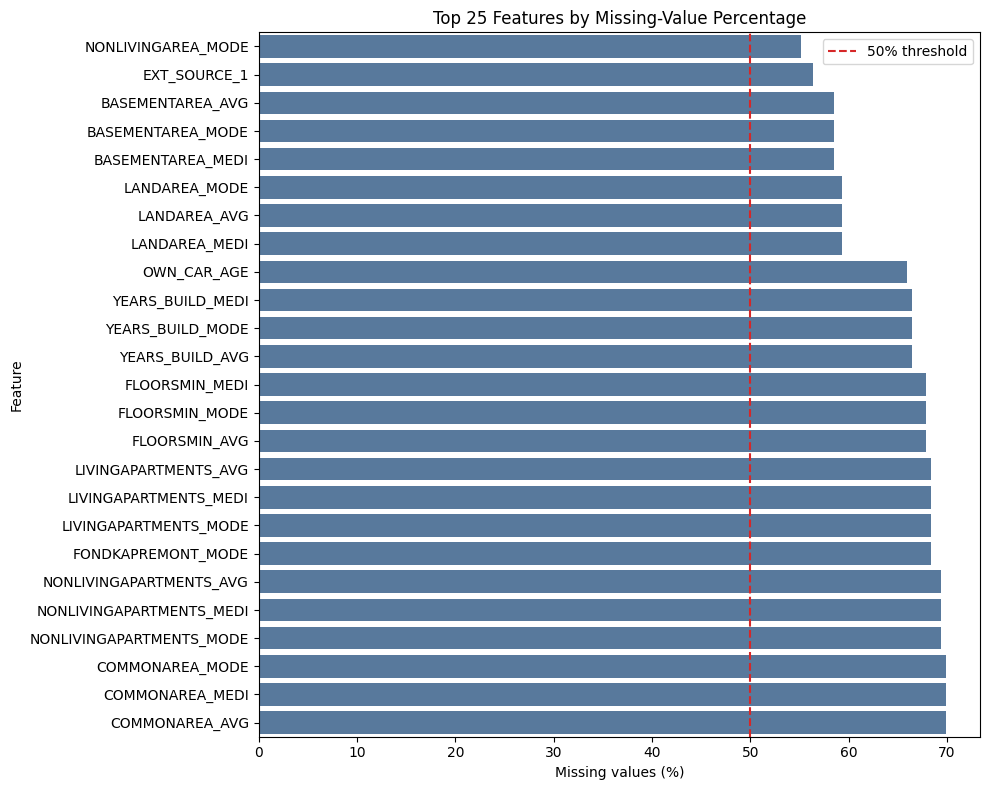

In [7]:
top_missing = missing_report.head(25).sort_values("missing_pct")
plt.figure(figsize=(10, 8))
sns.barplot(data=top_missing, x="missing_pct", y=top_missing.index, color="#4C78A8")
plt.axvline(50, color="#D62728", linestyle="--", linewidth=1.5, label="50% threshold")
plt.title("Top 25 Features by Missing-Value Percentage")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

67 out 122 columns have missing values and 41 of those 67 columns have more than 50% of values missing. These fields should not be removed without review because missingness may itself carry credit-risk information.

## Target distribution and class imbalance


In [8]:
target_summary = df["TARGET"].value_counts().sort_index().rename(index={0: "Repaid", 1: "Payment difficulty"})
target_table = pd.DataFrame({
    "count": target_summary,
    "percentage": target_summary / len(df) * 100,
})
display(target_table)

majority_to_minority = target_summary.loc["Repaid"] / target_summary.loc["Payment difficulty"]
print(f"Majority to minority ratio: {majority_to_minority:.2f}:1")

,count,percentage
TARGET,,
Repaid,282686,91.927118
Payment difficulty,24825,8.072882


Majority to minority ratio: 11.39:1


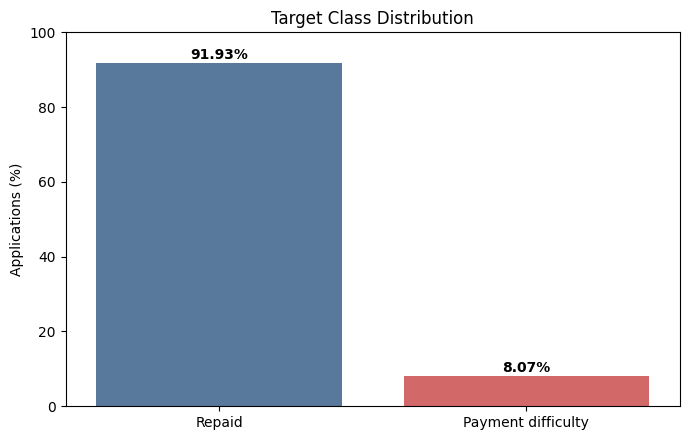

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=target_table.index, y=target_table["percentage"], ax=ax, palette=["#4C78A8", "#E45756"])
ax.set_title("Target Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Applications (%)")
for i, v in enumerate(target_table["percentage"]):
    ax.text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Only 8.07% of applications show payment difficulty, producing an 11.39:1 majority-to-minority ratio. Dataset has high class imbalance which must be handled before modeling.

## Sentinel values and suspicious extremes


In [10]:
sentinel_count = (df["DAYS_EMPLOYED"] == 365243).sum()
sentinel_rate = sentinel_count / len(df) * 100
print(f"DAYS_EMPLOYED sentinel count: {sentinel_count:,} ({sentinel_rate:.2f}%)")

suspicious_summary = pd.DataFrame({
    "min": df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]].min(),
    "median": df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]].median(),
    "max": df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]].max(),
})
display(suspicious_summary)

eda = df.copy()
eda["AGE_YEARS"] = -eda["DAYS_BIRTH"] / 365.25
eda["DAYS_EMPLOYED_CLEAN"] = eda["DAYS_EMPLOYED"].replace(365243, np.nan)
eda["EMPLOYMENT_YEARS"] = -eda["DAYS_EMPLOYED_CLEAN"] / 365.25

DAYS_EMPLOYED sentinel count: 55,374 (18.01%)


,min,median,max
AMT_INCOME_TOTAL,25650.0,147150.0,117000000.0
AMT_CREDIT,45000.0,513531.0,4050000.0
AMT_ANNUITY,1615.5,24903.0,258025.5
DAYS_BIRTH,-25229.0,-15750.0,-7489.0
DAYS_EMPLOYED,-17912.0,-1213.0,365243.0


## Key feature distributions

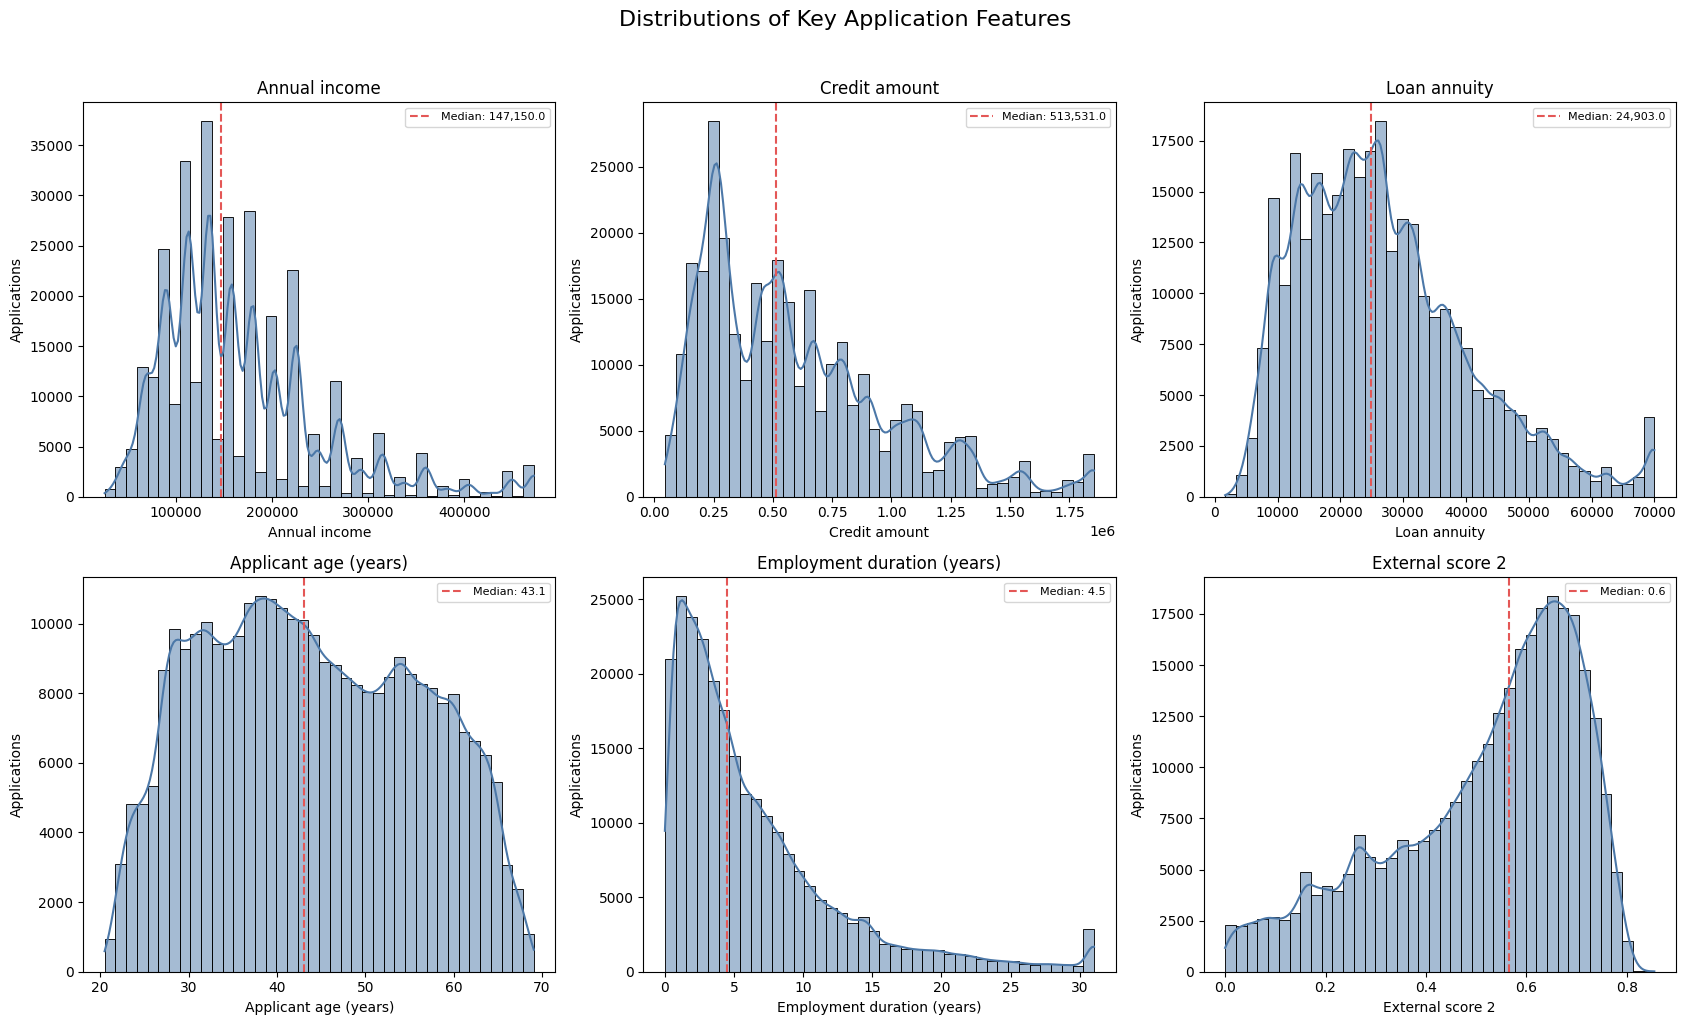

In [11]:
plot_specs = [
    ("AMT_INCOME_TOTAL", "Annual income", True),
    ("AMT_CREDIT", "Credit amount", True),
    ("AMT_ANNUITY", "Loan annuity", True),
    ("AGE_YEARS", "Applicant age (years)", False),
    ("EMPLOYMENT_YEARS", "Employment duration (years)", True),
    ("EXT_SOURCE_2", "External score 2", False),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (col, label, clip_upper) in zip(axes.flat, plot_specs):
    values = eda[col].dropna()
    if clip_upper:
        values = values.clip(upper=values.quantile(0.99))
    sns.histplot(values, bins=40, kde=True, ax=ax, color="#4C78A8")
    median = values.median()
    ax.axvline(median, color="#E45756", linestyle="--", label=f"Median: {median:,.1f}")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Applications")
    ax.legend(fontsize=8)

fig.suptitle("Distributions of Key Application Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Income, credit, annuity, and employment duration are strongly right-skewed, so the plots cap selected variables at the 99th percentile for readability without altering the stored data. Applicant age and EXT_SOURCE_2 are more smoothly distributed, while the employment sentinel must be replaced before modeling.

## Default rate across customer segments


In [12]:
segment_cols = [
    "NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"
]

def segment_default_table(column):
    return (
        eda.groupby(column, dropna=False)["TARGET"]
           .agg(applications="size", defaults="sum", default_rate="mean")
           .assign(default_rate_pct=lambda x: x["default_rate"] * 100)
           .sort_values("default_rate_pct", ascending=False)
    )

for column in segment_cols:
    print(f"\n{column}")
    display(segment_default_table(column).head(15))


NAME_CONTRACT_TYPE


,applications,defaults,default_rate,default_rate_pct
NAME_CONTRACT_TYPE,,,,
Cash loans,278232,23221,0.083459,8.345913
Revolving loans,29279,1604,0.054783,5.478329



NAME_INCOME_TYPE


,applications,defaults,default_rate,default_rate_pct
NAME_INCOME_TYPE,,,,
Maternity leave,5,2,0.400000,40.000000
Unemployed,22,8,0.363636,36.363636
Working,158774,15224,0.095885,9.588472
Commercial associate,71617,5360,0.074843,7.484257
State servant,21703,1249,0.057550,5.754965
Pensioner,55362,2982,0.053864,5.386366
Businessman,10,0,0.000000,0.000000
Student,18,0,0.000000,0.000000



OCCUPATION_TYPE


,applications,defaults,default_rate,default_rate_pct
OCCUPATION_TYPE,,,,
Low-skill Laborers,2093,359,0.171524,17.152413
Drivers,18603,2107,0.113261,11.326130
Waiters/barmen staff,1348,152,0.112760,11.275964
Security staff,6721,722,0.107424,10.742449
Laborers,55186,5838,0.105788,10.578770
Cooking staff,5946,621,0.104440,10.443996
Sales staff,32102,3092,0.096318,9.631799
Cleaning staff,4653,447,0.096067,9.606705
Realty agents,751,59,0.078562,7.856192



ORGANIZATION_TYPE


,applications,defaults,default_rate,default_rate_pct
ORGANIZATION_TYPE,,,,
Transport: type 3,1187,187,0.157540,15.754002
Industry: type 13,67,9,0.134328,13.432836
Industry: type 8,24,3,0.125000,12.500000
Restaurant,1811,212,0.117062,11.706240
Construction,6721,785,0.116798,11.679810
Cleaning,260,29,0.111538,11.153846
Industry: type 1,1039,115,0.110683,11.068335
Industry: type 3,3278,348,0.106162,10.616229
Realtor,396,42,0.106061,10.606061


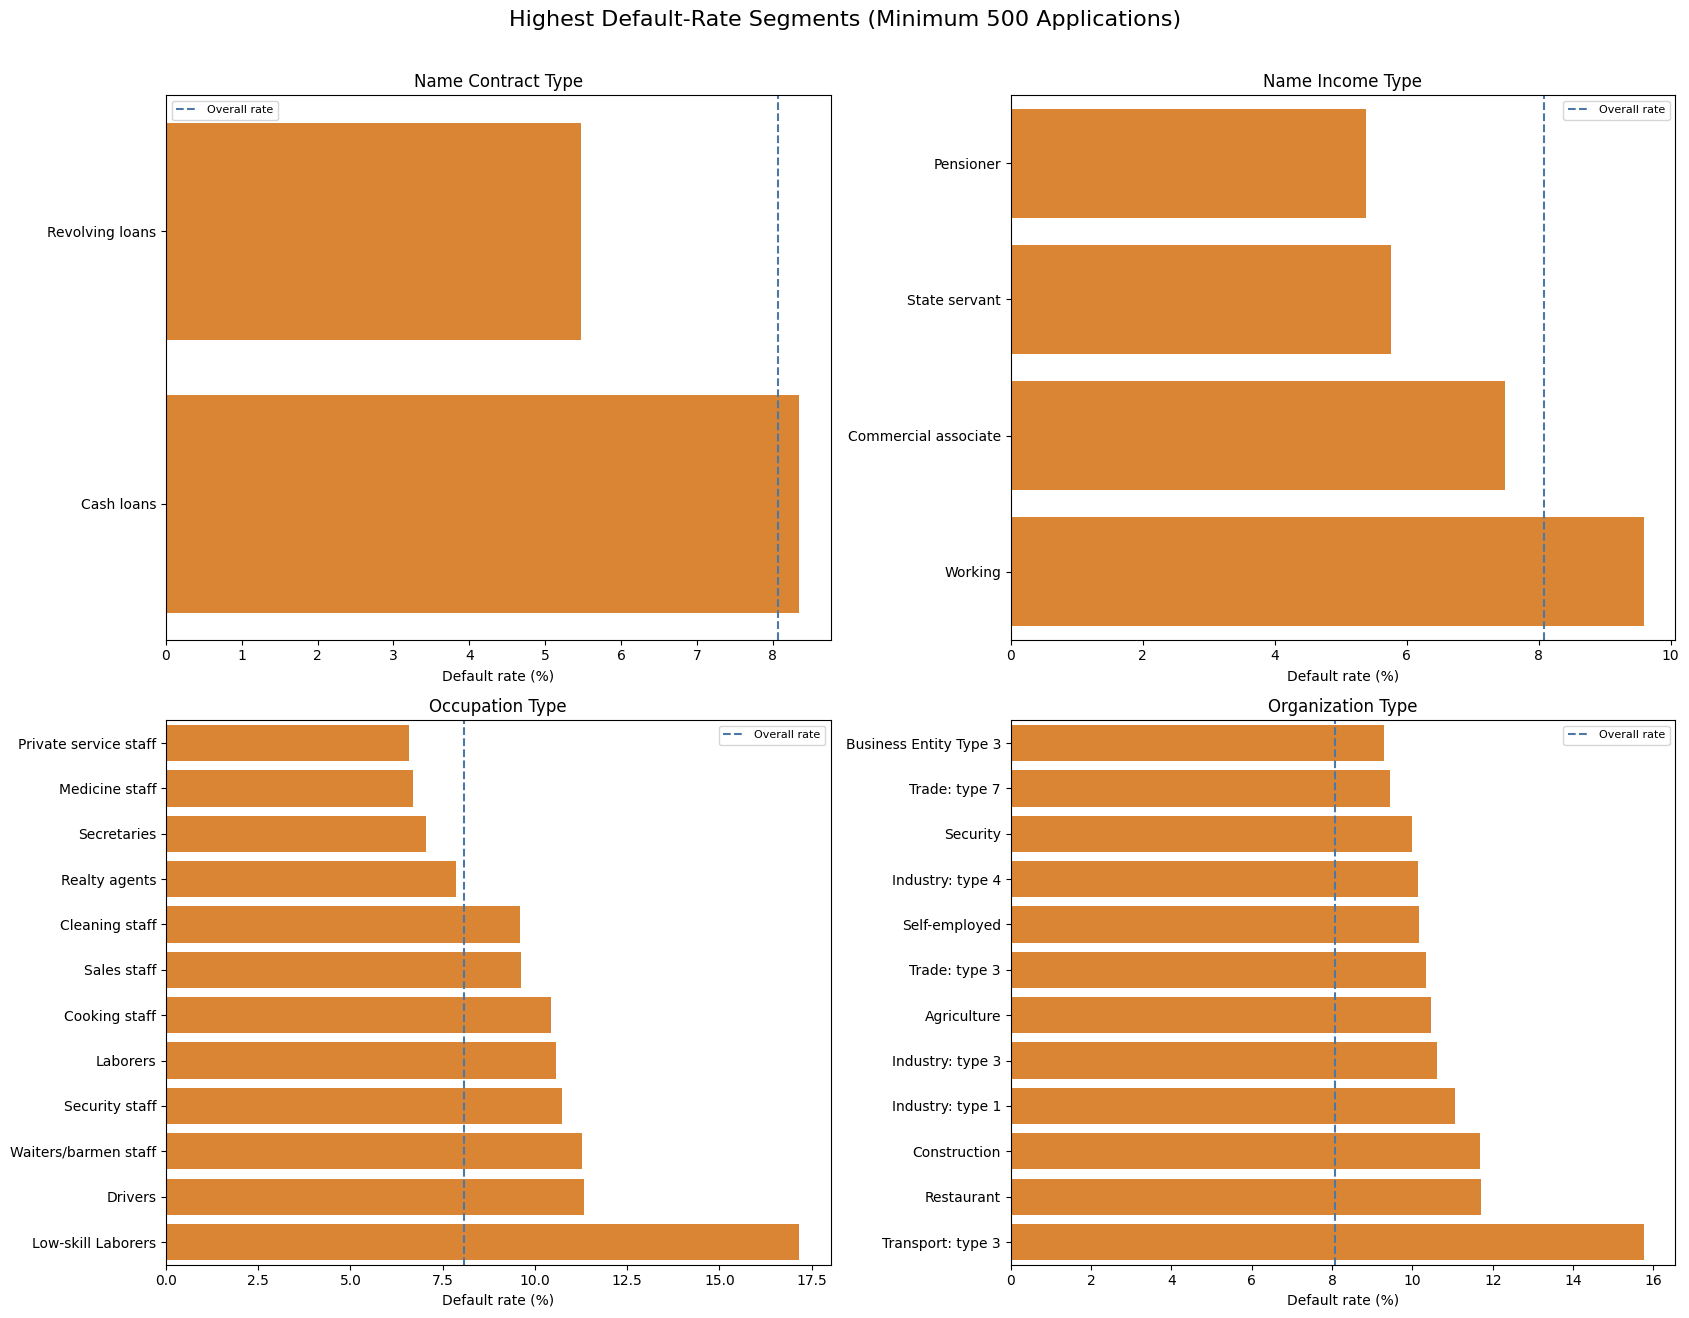

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(17, 13))
for ax, column in zip(axes.flat, segment_cols):
    table = segment_default_table(column)
    eligible = table[table["applications"] >= 500].head(12).sort_values("default_rate_pct")
    sns.barplot(data=eligible, x="default_rate_pct", y=eligible.index, ax=ax, color="#F58518")
    ax.axvline(eda["TARGET"].mean() * 100, color="#4C78A8", linestyle="--",
               label="Overall rate")
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Default rate (%)")
    ax.set_ylabel("")
    ax.legend(fontsize=8)

fig.suptitle("Highest Default-Rate Segments (Minimum 500 Applications)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Cash-loan applicants default more often than revolving-loan applicants, and several occupational or organizational groups sit above the 8.07% portfolio rate.
## Numeric relationships with TARGET

In [14]:
numeric_for_corr = eda.select_dtypes(include=np.number).copy()
target_corr = (
    numeric_for_corr.corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
)
top_corr = target_corr.head(15)
display(top_corr.to_frame("correlation_with_TARGET"))

,correlation_with_TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
AGE_YEARS,-0.078239
DAYS_BIRTH,0.078239
DAYS_EMPLOYED_CLEAN,0.074958
EMPLOYMENT_YEARS,-0.074958
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218


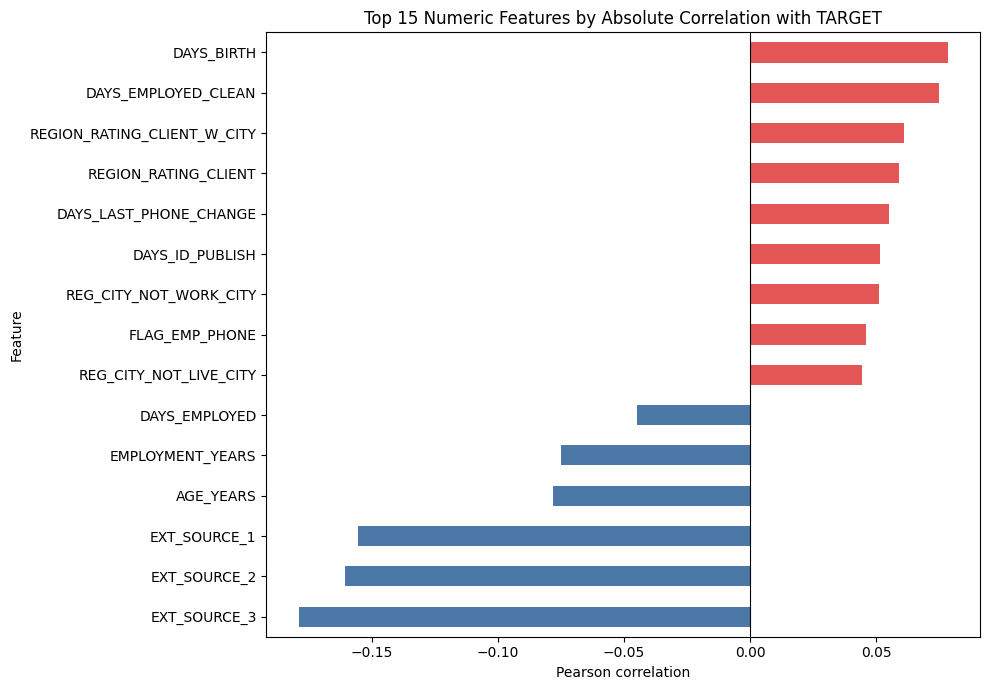

In [15]:
plt.figure(figsize=(10, 7))
colors = ["#E45756" if value > 0 else "#4C78A8" for value in top_corr.sort_values()]
top_corr.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Numeric Features by Absolute Correlation with TARGET")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

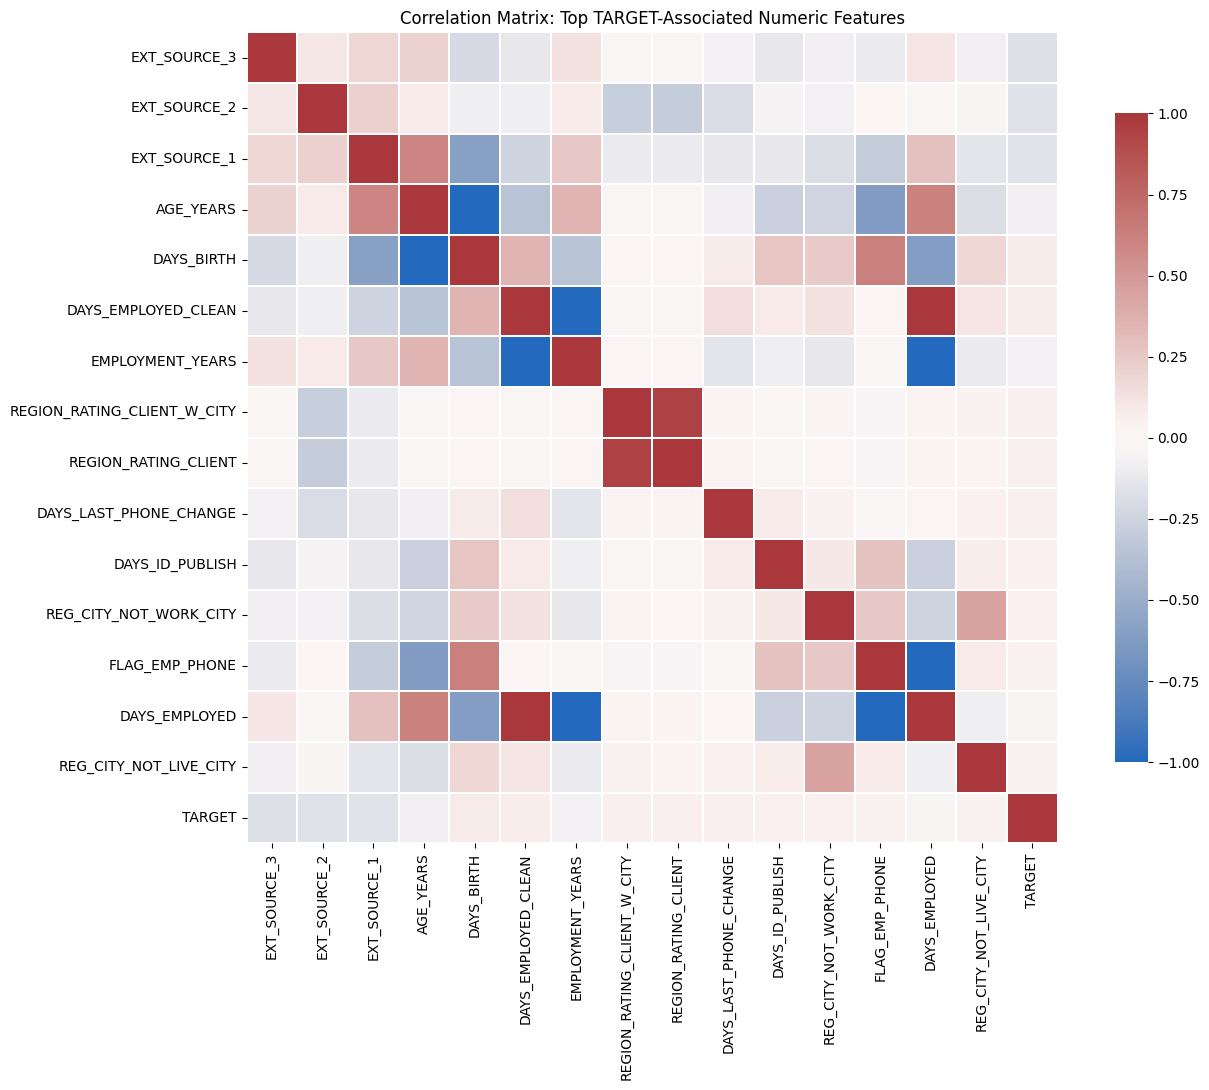

In [16]:
heatmap_cols = top_corr.index.tolist() + ["TARGET"]
corr_matrix = numeric_for_corr[heatmap_cols].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="vlag", center=0, square=True, linewidths=0.25, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Top TARGET-Associated Numeric Features")
plt.tight_layout()
plt.show()

The three external scores have the strongest absolute numeric relationships with TARGET, while age and employment history provide weaker secondary signals. The heatmap also exposes correlated feature families. Tree models will be preferable for modeling.

## External scores versus default

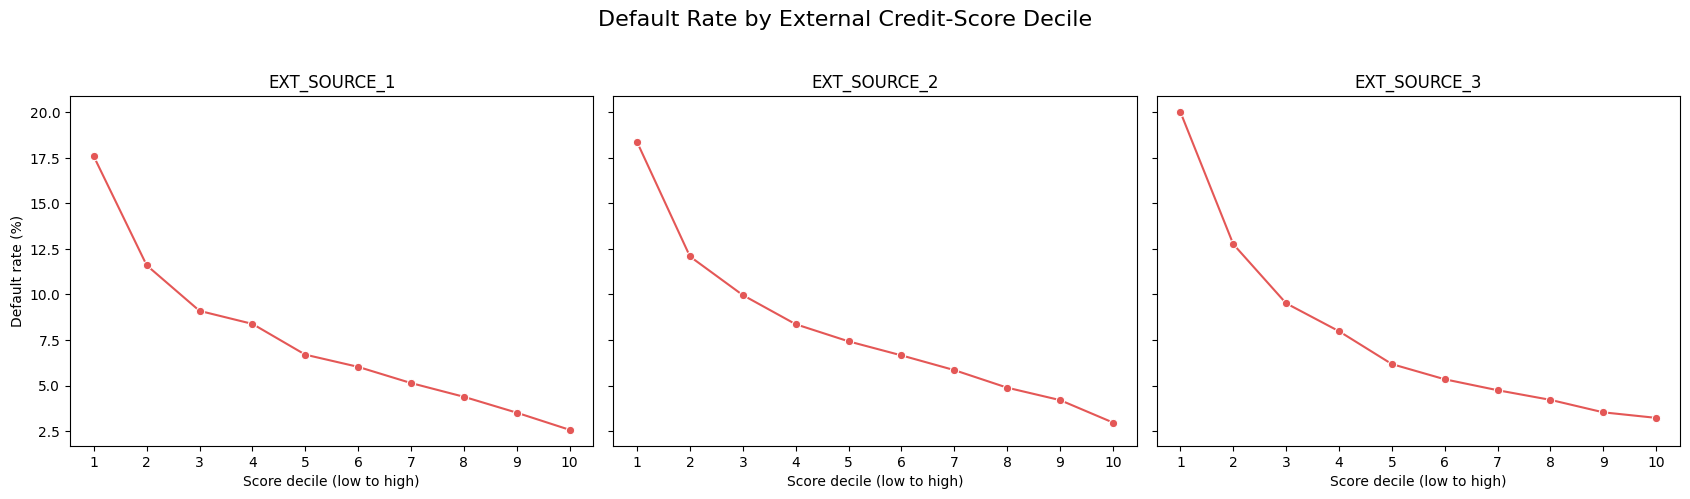

In [17]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)

for ax, col in zip(axes, ext_cols):
    temp = eda[[col, "TARGET"]].dropna().copy()
    temp["decile"] = pd.qcut(temp[col], 10, labels=False, duplicates="drop") + 1
    rates = temp.groupby("decile")["TARGET"].mean().mul(100)
    sns.lineplot(x=rates.index, y=rates.values, marker="o", ax=ax, color="#E45756")
    ax.set_title(col)
    ax.set_xlabel("Score decile (low to high)")
    ax.set_ylabel("Default rate (%)")
    ax.set_xticks(rates.index)

fig.suptitle("Default Rate by External Credit-Score Decile", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

Default rates fall consistently as each external-score decile increases, confirming that higher external scores correspond to lower observed risk. These features should be retained regardless of their missingness.

## Bureau records


,size,mean,default_rate_pct
bureau_count_band,,,
0,44020,0.101249,10.124943
1-2,71707,0.082028,8.202825
3-5,86883,0.074008,7.400757
6-10,72624,0.074562,7.456213
11+,32277,0.081823,8.182297


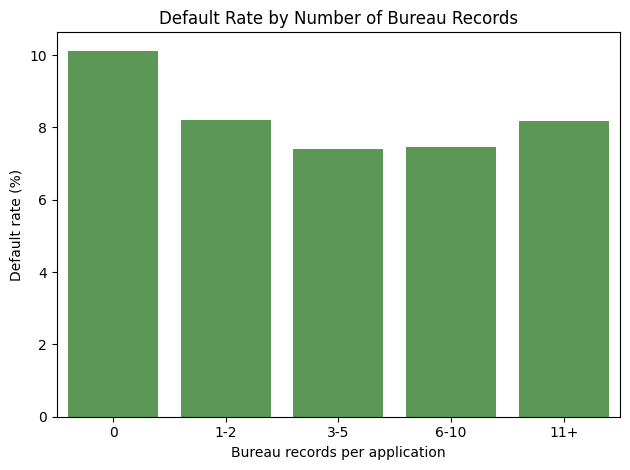

In [18]:
BUREAU_PATH = Path("../data/bureau.csv")

bureau = pd.read_csv(BUREAU_PATH)

bureau_counts = (
    bureau.groupby("SK_ID_CURR")
    .size()
    .rename("num_bureau_records")
)

bureau_eda = eda.merge(bureau_counts, on="SK_ID_CURR", how="left")
bureau_eda["num_bureau_records"] = bureau_eda["num_bureau_records"].fillna(0)

bureau_eda["bureau_count_band"] = pd.cut(
    bureau_eda["num_bureau_records"],
    bins=[-1, 0, 2, 5, 10, np.inf],
    labels=["0", "1-2", "3-5", "6-10", "11+"],
)

bureau_rates = (
    bureau_eda.groupby("bureau_count_band", observed=False)["TARGET"]
    .agg(["size", "mean"])
)

bureau_rates["default_rate_pct"] = bureau_rates["mean"] * 100

display(bureau_rates)

sns.barplot(
    data=bureau_rates.reset_index(),
    x="bureau_count_band",
    y="default_rate_pct",
    color="#54A24B",
)

plt.title("Default Rate by Number of Bureau Records")
plt.xlabel("Bureau records per application")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

Applicants with no bureau history have the highest observed default rate at 10.12%, compared with roughly 7.40% for applicants holding three to five bureau records. Risk rises again for applicants with 11 or more records, suggesting a non-linear relationship that is better represented through aggregated bureau features than a single linear count.